In [1]:
from pathlib import Path
# import warnings
# warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from backtesting import Backtest, Strategy
from backtesting.lib import crossover

# pd.set_option("display.max_columns", 100)
# pd.set_option("display.width", 160)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

/Users/fanzhaobing/www/github.com/langgo/QuantHub/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [72]:
!uv add talib 

import talib as ta

  × No solution found when resolving dependencies for split (markers:               
  │ python_full_version >= '3.14' and sys_platform == 'win32'):
  ╰─▶ Because talib was not found in the package registry and your project
      depends on talib, we can conclude that your project's requirements are
      unsatisfiable.

hint: While the active Python version is 3.12, the resolution failed for other Python versions supported by your project. Consider limiting your project's supported Python versions using `requires-python`.
hint: If you want to add the package regardless of the failed resolution, provide the `--frozen` flag to skip locking and syncing

ModuleNotFoundError: No module named 'talib'

In [78]:
!uv add pandas-ta

  × No solution found when resolving dependencies for split (markers:               
  │ python_full_version >= '3.14' and sys_platform == 'win32'):
  ╰─▶ Because all versions of pandas-ta depend on numba==0.61.2 and
      numba==0.61.2 depends on numpy>=1.24,<2.3, we can conclude that all
      versions of pandas-ta depend on numpy>=1.24,<2.3.
      And because your project depends on numpy>=2.5.2 and pandas-ta, we can
      conclude that your project's requirements are unsatisfiable.

hint: While the active Python version is 3.12, the resolution failed for other Python versions supported by your project. Consider limiting your project's supported Python versions using `requires-python`.
hint: If you want to add the package regardless of the failed resolution, provide the `--frozen` flag to skip locking and syncing

In [77]:
!uv add pandas-ta

import pandas_ta as ta

  × No solution found when resolving dependencies for split (markers:               
  │ python_full_version >= '3.14' and sys_platform == 'win32'):
  ╰─▶ Because all versions of pandas-ta depend on numba==0.61.2 and
      numba==0.61.2 depends on numpy>=1.24,<2.3, we can conclude that all
      versions of pandas-ta depend on numpy>=1.24,<2.3.
      And because your project depends on numpy>=2.5.2 and pandas-ta, we can
      conclude that your project's requirements are unsatisfiable.

hint: While the active Python version is 3.12, the resolution failed for other Python versions supported by your project. Consider limiting your project's supported Python versions using `requires-python`.
hint: If you want to add the package regardless of the failed resolution, provide the `--frozen` flag to skip locking and syncing

ModuleNotFoundError: No module named 'pandas_ta'

In [8]:
!uv add akshare-proxy-patch

Resolved 133 packages in 1.81s                                       
Prepared 1 package in 237ms                                              
Installed 1 package in 21ms=0.5.0                           
 + akshare-proxy-patch==0.5.0


In [9]:
import akshare_proxy_patch
akshare_proxy_patch.install_patch(
    "101.201.173.125",  # 网关，通常无需修改
    auth_token="2026082911LTOKDL", # 需从插件官网获取
    retry=30,
)

In [10]:
import akshare as ak

In [12]:
raw = ak.stock_zh_a_hist(
        symbol="603993",
        period="daily",
        start_date="20200101",
        end_date="20260829",
        adjust="qfq",
        timeout=30,
    )

In [16]:
type(raw)

pandas.DataFrame

In [14]:
raw.to_csv("data/603993_20200101_20260829_qfq_raw.csv")

In [15]:
import os 
os.getcwd()

'/Users/fanzhaobing/www/github.com/langgo/QuantHub/notebooks/data'

In [21]:
raw.columns

Index(['日期', '股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额',
       '换手率'],
      dtype='str')

In [22]:
raw.index

RangeIndex(start=0, stop=1614, step=1)

In [23]:
date_col = "日期"
rename = {
    date_col: "Date",
    "开盘": "Open",
    "最高": "High",
    "最低": "Low",
    "收盘": "Close",
    "成交量": "Volume",
    "成交额": "Amount",
    "振幅": "Amplitude",
    "涨跌幅": "PctChange",
    "涨跌额": "Change",
    "换手率": "Turnover",
    "均价": "AvgPrice",
}
df = raw.rename(columns=rename).copy()

In [24]:
df

,Date,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover
0,2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39
1,2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76
2,2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87
3,2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04
4,2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22
...,...,...,...,...,...,...,...,...,...,...,...,...
1609,2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72
1610,2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07
1611,2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67
1612,2026-08-27,603993,19.23,19.51,19.63,19.15,2584209,5.003966e+09,2.45,-0.41,-0.08,1.48


In [35]:
df["Date"][0], pd.to_datetime(df["Date"][0])

(datetime.date(2020, 1, 2), Timestamp('2020-01-02 00:00:00'))

In [36]:
df["Date"] = pd.to_datetime(df["Date"])

In [38]:
df = df.set_index("Date").sort_index()

In [40]:
keep = [
    "Open", "High", "Low", "Close", "Volume",
    "Amount", "Amplitude", "PctChange", "Change", "Turnover", "AvgPrice",
]
keep = [c for c in keep if c in df.columns]

for c in keep:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [42]:
type(df[keep])

pandas.DataFrame

In [43]:
len(df)

1614

In [44]:
df[keep].dropna(subset=["Open", "High", "Low", "Close"])

,Open,High,Low,Close,Volume,Amount,Amplitude,PctChange,Change,Turnover
Date,,,,,,,,,,
2020-01-02,3.47,3.53,3.39,3.45,2449631,1.071797e+09,4.07,0.29,0.01,1.39
2020-01-03,3.50,3.65,3.40,3.56,3113213,1.390301e+09,7.25,3.19,0.11,1.76
2020-01-06,3.54,3.73,3.52,3.57,3306883,1.498801e+09,5.90,0.28,0.01,1.87
2020-01-07,3.53,3.57,3.45,3.50,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04
2020-01-08,3.50,3.59,3.46,3.54,2153188,9.581397e+08,3.71,1.14,0.04,1.22
...,...,...,...,...,...,...,...,...,...,...
2026-08-24,19.00,19.35,18.72,18.99,3001068,5.725236e+09,3.38,1.99,0.37,1.72
2026-08-25,18.80,18.94,18.18,18.42,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07
2026-08-26,18.56,19.99,18.56,19.59,4669119,9.082612e+09,7.76,6.35,1.17,2.67


In [45]:
len(df)

1614

In [46]:
df.to_csv("data/603993_20200101_20260829_qfq_df.csv", index_label="Date")

In [51]:
df.tail()

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover
Date,,,,,,,,,,,
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67
2026-08-27,603993,19.23,19.51,19.63,19.15,2584209,5.003966e+09,2.45,-0.41,-0.08,1.48
2026-08-28,603993,19.50,19.51,19.73,19.11,1869022,3.629096e+09,3.18,0.00,0.00,1.07


In [52]:
out = df.copy()

In [53]:
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover
Date,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67


In [54]:
out["mom_20"] = out["Close"].pct_change(20)

In [55]:
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover,mom_20
Date,,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39,NaN
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76,NaN
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87,NaN
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04,NaN
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72,-0.019112
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07,-0.030526
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67,0.026730


In [58]:
out["vol_20"] = out["Close"].pct_change().rolling(20).std() * np.sqrt(252)

In [59]:
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover,mom_20,vol_20
Date,,,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39,NaN,NaN
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76,NaN,NaN
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87,NaN,NaN
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04,NaN,NaN
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72,-0.019112,0.491692
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07,-0.030526,0.498884
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67,0.026730,0.549109


In [60]:
out["ma_gap_20"] = out["Close"] / out["Close"].rolling(20).mean() - 1
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover,mom_20,vol_20,ma_gap_20
Date,,,,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39,NaN,NaN,NaN
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76,NaN,NaN,NaN
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87,NaN,NaN,NaN
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04,NaN,NaN,NaN
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72,-0.019112,0.491692,-0.011349
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07,-0.030526,0.498884,-0.039575
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67,0.026730,0.549109,0.020073


In [61]:
out["volume_ratio_20"] = out["Volume"] / out["Volume"].rolling(20).mean()
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover,mom_20,vol_20,ma_gap_20,volume_ratio_20
Date,,,,,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39,NaN,NaN,NaN,NaN
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76,NaN,NaN,NaN,NaN
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87,NaN,NaN,NaN,NaN
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04,NaN,NaN,NaN,NaN
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72,-0.019112,0.491692,-0.011349,1.245837
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07,-0.030526,0.498884,-0.039575,0.770654
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67,0.026730,0.549109,0.020073,1.825712


In [62]:
def RSI(values, n=14):
    values = pd.Series(values)
    diff = values.diff()
    gain = diff.clip(lower=0)
    loss = -diff.clip(upper=0)
    rs = gain.ewm(alpha=1 / n, adjust=False).mean() / loss.ewm(alpha=1 / n, adjust=False).mean()
    return 100 - 100 / (1 + rs)

out["rsi_14"] = RSI(out["Close"], 14).values

In [63]:
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover,mom_20,vol_20,ma_gap_20,volume_ratio_20,rsi_14
Date,,,,,,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39,NaN,NaN,NaN,NaN,NaN
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76,NaN,NaN,NaN,NaN,100.000000
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87,NaN,NaN,NaN,NaN,100.000000
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04,NaN,NaN,NaN,NaN,95.025381
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22,NaN,NaN,NaN,NaN,95.173145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72,-0.019112,0.491692,-0.011349,1.245837,50.462505
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07,-0.030526,0.498884,-0.039575,0.770654,46.252904
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67,0.026730,0.549109,0.020073,1.825712,54.620936


In [64]:
if "Amount" in out.columns:
    out["amount_ratio_20"] = out["Amount"] / out["Amount"].rolling(20).mean()
if "Turnover" in out.columns:
    out["turnover_ma_20"] = out["Turnover"].rolling(20).mean()
out

,股票代码,Open,Close,High,Low,Volume,Amount,Amplitude,PctChange,Change,Turnover,mom_20,vol_20,ma_gap_20,volume_ratio_20,rsi_14,amount_ratio_20,turnover_ma_20
Date,,,,,,,,,,,,,,,,,,
2020-01-02,603993,3.47,3.45,3.53,3.39,2449631,1.071797e+09,4.07,0.29,0.01,1.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,603993,3.50,3.56,3.65,3.40,3113213,1.390301e+09,7.25,3.19,0.11,1.76,NaN,NaN,NaN,NaN,100.000000,NaN,NaN
2020-01-06,603993,3.54,3.57,3.73,3.52,3306883,1.498801e+09,5.90,0.28,0.01,1.87,NaN,NaN,NaN,NaN,100.000000,NaN,NaN
2020-01-07,603993,3.53,3.50,3.57,3.45,1834331,8.097028e+08,3.36,-1.96,-0.07,1.04,NaN,NaN,NaN,NaN,95.025381,NaN,NaN
2020-01-08,603993,3.50,3.54,3.59,3.46,2153188,9.581397e+08,3.71,1.14,0.04,1.22,NaN,NaN,NaN,NaN,95.173145,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-24,603993,19.00,18.99,19.35,18.72,3001068,5.725236e+09,3.38,1.99,0.37,1.72,-0.019112,0.491692,-0.011349,1.245837,50.462505,1.228257,1.3805
2026-08-25,603993,18.80,18.42,18.94,18.18,1863339,3.440587e+09,4.00,-3.00,-0.57,1.07,-0.030526,0.498884,-0.039575,0.770654,46.252904,0.735985,1.3860
2026-08-26,603993,18.56,19.59,19.99,18.56,4669119,9.082612e+09,7.76,6.35,1.17,2.67,0.026730,0.549109,0.020073,1.825712,54.620936,1.834363,1.4655


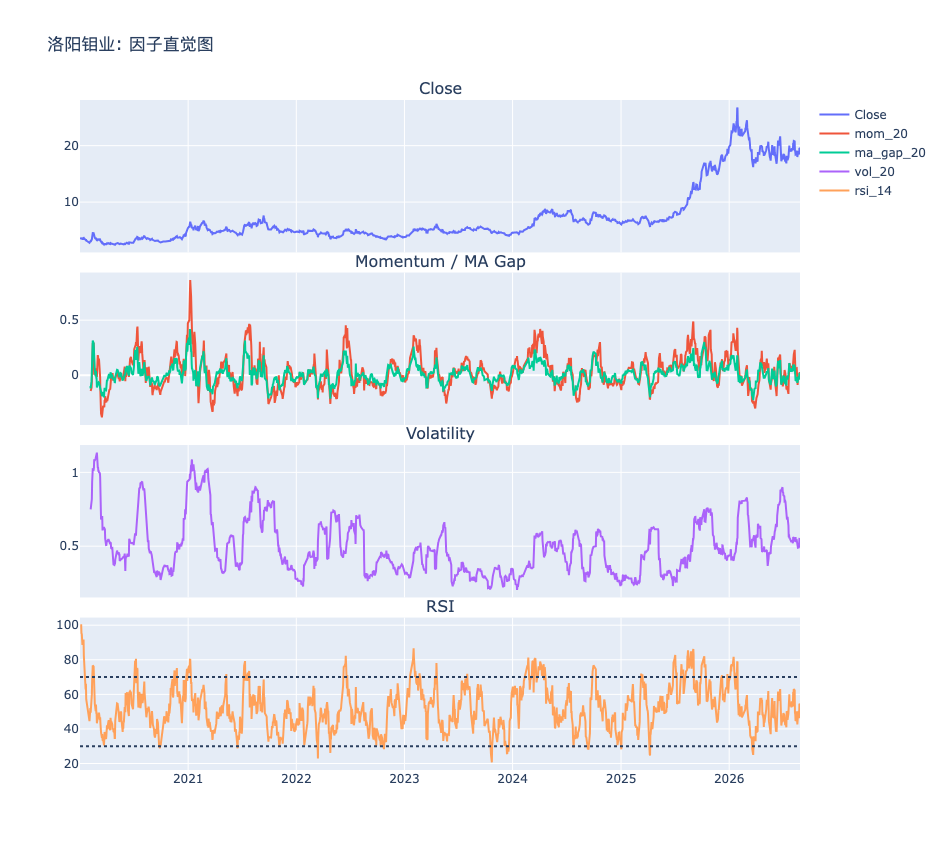

In [71]:
def plot_factors(df, name):
    try:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots

        fig = make_subplots(
            rows=4,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.03,
            subplot_titles=("Close", "Momentum / MA Gap", "Volatility", "RSI"),
        )
        fig.add_trace(go.Scatter(x=df.index, y=df["Close"], name="Close"), row=1, col=1)
        fig.add_trace(go.Scatter(x=df.index, y=df["mom_20"], name="mom_20"), row=2, col=1)
        fig.add_trace(go.Scatter(x=df.index, y=df["ma_gap_20"], name="ma_gap_20"), row=2, col=1)
        fig.add_trace(go.Scatter(x=df.index, y=df["vol_20"], name="vol_20"), row=3, col=1)
        fig.add_trace(go.Scatter(x=df.index, y=df["rsi_14"], name="rsi_14"), row=4, col=1)
        fig.add_hline(y=70, line_dash="dot", row=4, col=1)
        fig.add_hline(y=30, line_dash="dot", row=4, col=1)
        fig.update_layout(height=850, title=f"{name}: 因子直觉图")
        fig.show()
    except ImportError:
        df[["Close", "mom_20", "ma_gap_20", "vol_20", "rsi_14"]].plot(subplots=True, figsize=(12, 8))

plot_factors(out, "洛阳钼业")